In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from skglm.datafits import Cox
from skglm.penalties import L1
from skglm.solvers import ProxNewton
from skglm.utils.jit_compilation import compiled_clone
from lifelines import CoxPHFitter
from lifelines.fitters.weibull_aft_fitter import WeibullAFTFitter

np.random.seed(42)

In [2]:
##  Data-generating process for the RCT and OBS are implemented in this cell.
max_follow_up = 200 

def generate_rct_treatment(row):
    return np.random.binomial(1, 0.5)


def generate_obs_treatment(row):
    # Don't change the treatment assignment process for OBS
    if row["X1"] == -1:
        return np.random.binomial(1, 0.1)
    else:
        return np.random.binomial(1, 0.9)
        # if row["U1"] == -1:
        #     return np.random.binomial(1, 0.9)
        # else:
        #     return np.random.binomial(1, 0.1)


def generate_time_to_treatment_init_rct(row): 
    return 0


def generate_time_to_treatment_init(row): 
    # params 
    lambda_X1_neg1 = 0.05 
    # lambda_X1_1_U1_neg1 = 0.2 
    # lambda_X1_1_U1_pos1 = 0.05
    lambda_X1_1_U1_neg1 = 0.95 
    lambda_X1_1_U1_pos1 = 0.95 

    if row["A"] == 0: 
        return 0 
    else: 
        if row["X1"] == -1: 
            return np.random.normal(1 / lambda_X1_neg1, 0.1)
            # return np.random.exponential(1 / lambda_X1_neg1)
        else: 
            return np.random.normal(1 / lambda_X1_1_U1_neg1, 0.1)
            # if row["U1"] < 0:
            #     return np.random.normal(1 / lambda_X1_1_U1_neg1, 0.1)
            #     # return np.random.exponential(1 / lambda_X1_1_U1_neg1)
            # elif row["U1"] >= 0: 
            #     return np.random.normal(1 / lambda_X1_1_U1_pos1, 0.1) 
            #     # return np.random.exponential(1 / lambda_X1_1_U1_pos1) 


def generate_time_to_event(row): 
    lambda_baseline = 0.5 
    beta_X1 = 0.5 # effect of X_1 on HR 
    beta_A  = -1  # effect of A on HR (reduces hazard)
    delta = 5. # shift in the distribution of time to event

    # compute before hazard (for non-treatment) and after hazard (for treatment)
    lambda_before = lambda_baseline * np.exp(beta_X1 * row["X1"])
    lambda_after  = lambda_before * np.exp(beta_A * row["A"])

    # generate time to events 
    if row["A"] == 0: 
        return np.random.normal(1 / lambda_before) + delta
        # return np.random.exponential(1 / lambda_before) 
        # => note that time to events under exponential distribution are super finicky
    else: 
        return row["Ta"] + np.random.normal(1 / lambda_after) + delta
        # return row["Ta"] + np.random.exponential(1 / lambda_after)


def generate_event_indicator(row): 
    # assume no other censoring except administrative censoring
    if row["Ty"] <= max_follow_up: 
        return 1
    else: 
        return 0 
    

def generate_observed_time_to_event(row): 
    return min(row["Ty"], max_follow_up)


def generate_treatment_and_outcome(df, fn_tr, fn_tr_init, fn_event, 
                                    fn_censor, fn_event_obs):
    # A, Ta, Ty, E, Ty_obs
    df["A"]  = df.apply(fn_tr, axis=1)
    df["Ta"] = df.apply(fn_tr_init, axis=1)
    df["Ty"] = df.apply(fn_event, axis=1)
    df["E"]  = df.apply(fn_censor, axis=1)
    df["Ty_obs"] = df.apply(fn_event_obs, axis=1)


def split_sample(d, row): 
     # first half of the interval
    d1 = d.copy()
    d1["T0"] = 0
    d1["Ty"] = row["Ta"]
    d1["Ty_obs"] = row["Ta"]
    d1["E"]  = 0
    d1["A_timevarying"] = 0

    # second half of the interval
    d2 = d.copy()
    d2["T0"] = row["Ta"]
    d2["Ty"] = row["Ty"]
    d2["Ty_obs"] = row["Ty_obs"]
    d2["E"]  = row["E"]
    d2["A_timevarying"] = 1

    return d1, d2


def correct_immortal_bias(df, correction_type="delayed_entry"): 
    # only relevant for splitting observations and/or time-varying covariates
    # cols: "X1", "U1", "A", "Ta", "Ty", "E", "Ty_obs"
    if correction_type == "delayed_entry":
        # Add a new column 'T0' and set its values based on the condition
        df['T0'] = 0
        df.loc[df['A'] == 1, 'T0'] = df.loc[df['A'] == 1, 'Ta']
    elif correction_type == "time_varying":
        # Initialize new columns if they don't exist
        if 'T0' not in df.columns:
            df['T0'] = 0
        if 'A_timevarying' not in df.columns:
            df['A_timevarying'] = 0

        rows_to_add = []
        indices_to_drop = []

        for index, row in df.iterrows():
            if row['A'] == 1:
                # Split the row into two new rows
                d1, d2 = split_sample(row)
                # Mark the original row for deletion
                indices_to_drop.append(index)
                # Append the new rows to the list
                rows_to_add.append(d1)
                rows_to_add.append(d2)
            else:
                # Update existing row
                df.at[index, 'T0'] = 0
                df.at[index, 'A_timevarying'] = 0

        # Drop the original rows that have been split
        df.drop(indices_to_drop, inplace=True)
        # Append new rows to 'df' directly
        for new_row in rows_to_add:
            df.loc[len(df)] = new_row
    else:
        raise ValueError("Given improper correction_type.")


##  function for generating and logging the predictions & stats related to the fitted outcome models
def log_om_res(df, covs, model):

    if model == "DTR":
        om_T0 = DecisionTreeRegressor().fit(df.query("A==0")[covs], df.query("A==0")["Ty_obs"])
        om_T1 = DecisionTreeRegressor().fit(df.query("A==1")[covs], df.query("A==1")["Ty_obs"])
        df["hat_Y0"] = om_T0.predict(df[covs])  # log counter-factual outcome predictions for T=0
        df["hat_Y1"] = om_T1.predict(df[covs])  # log counter-factual outcome predictions for T=1
    elif model == "PS": # parametric survival model 
        # exponential or weibull 
        wf_T0 = WeibullAFTFitter().fit(df.query("A==0"), duration_col="Ty_obs", event_col="E", 
                                   formula=" + ".join(covs))
        wf_T1 = WeibullAFTFitter().fit(df.query("A==1"), duration_col="Ty_obs", event_col="E", 
                                   formula=" + ".join(covs))
        print(wf_T1.print_summary())
        df["hat_Y0"] = wf_T0.predict_median(df)
        df["hat_Y1"] = wf_T1.predict_median(df)
    elif model == "Cox-TV": 
        correct_immortal_bias(df, correction_type="time_varying") 
        cph_S = CoxPHFitter()
        cph_S.fit(df, duration_col="Ty_obs", event_col="E", start_col="T0", formula="A_timevarying + X1")
    elif model == "Cox-DE": #delayed entry
        correct_immortal_bias(df, correction_type="delayed_entry")
        cph_T0 = CoxPHFitter().fit(df.query("A==0"), duration_col="Ty_obs", event_col="E", 
                                   entry_col="T0", formula=" + ".join(covs))
        cph_T1 = CoxPHFitter().fit(df.query("A==1"), duration_col="Ty_obs", event_col="E", 
                                   entry_col="T0", formula=" + ".join(covs))
        print(cph_T1.print_summary())
        df["hat_Y0"] = cph_T0.predict_median(df)
        df["hat_Y1"] = cph_T1.predict_median(df)
    elif model == "Cox": 
        cph_T0 = CoxPHFitter().fit(df.query("A==0"), duration_col="Ty_obs", event_col="E", 
                                   formula=" + ".join(covs))
        cph_T1 = CoxPHFitter().fit(df.query("A==1"), duration_col="Ty_obs", event_col="E", 
                                   formula=" + ".join(covs))
        print(cph_T1.print_summary())
        df["hat_Y0"] = cph_T0.predict_median(df)
        df["hat_Y1"] = cph_T1.predict_median(df)

    df["SE_Y0"] = (df.query("A==0")["Ty_obs"] - df.query("A==0")["hat_Y0"]) ** 2  # log instance-wise squared-error of the outcome model for T=0
    df["SE_Y1"] = (df.query("A==1")["Ty_obs"] - df.query("A==1")["hat_Y1"]) ** 2  # log instance-wise squared-error of the outcome model for T=1


def log_ps_res(df, covs, model):
    if model == "DTC":
        psm = DecisionTreeClassifier().fit(df[covs], df["A"])
        
    df["hat_P(A=1)"] = psm.predict_proba(df[covs])[:,1]
    df["BCELoss_A"] = - df["A"] * np.log(df["hat_P(A=1)"]) - (1 - df["A"]) * np.log(1 - df["hat_P(A=1)"])


def log_sm_res(df, covs, model):
    if model == "DTC":
        sm = DecisionTreeClassifier().fit(df[covs], df["S"])
    df["hat_P(S=1)"] = sm.predict_proba(df[covs])[:,1]


def psi0(row):
    if row["S"] == 1:
        return 0
    else:
        t_ind = row["A"]
        p_s1, p_t1 = row["hat_P(S=1)"], row["hat_P(A=1)"]
        y, mu0, mu1 = row["Ty_obs"], row["hat_Y0"], row["hat_Y1"]

        term_1 = mu1 - mu0
        term_2 = t_ind * (y - mu1) / p_t1
        term_3 = (1 - t_ind) * (y - mu0) / (1 - p_t1)

        return (term_1 + term_2 - term_3)/ (1 - p_s1)


def psi1(row):
    if row["S"] == 0:
        return 0
    else:
        t_ind = row["A"]
        p_s1, p_t1 = row["hat_P(S=1)"], row["hat_P(A=1)"]
        y, mu0, mu1 = row["Ty_obs"], row["hat_Y0"], row["hat_Y1"]

        term_1 = mu1 - mu0
        term_2 = t_ind * (y - mu1) / p_t1
        term_3 = (1 - t_ind) * (y - mu0) / (1 - p_t1)

        return (term_1 + term_2 - term_3) / p_s1
    

def calc_contrasts(df):
    df["psi0"] = df.apply(psi0, axis=1)
    df["psi1"] = df.apply(psi1, axis=1)
    df["psi"] = df["psi1"] - df["psi0"]

In [3]:
n_covs = 1
n_unmeasured_covs = 1
covs = [f'X{i+1}' for i in range(n_covs)] 
unmeasured_covs = [f'U{i+1}' for i in range(n_unmeasured_covs)] 

n_rct = 1000
n_obs = 10000

X_rct = np.random.choice([-1, 1], size=(n_rct, n_covs))
U_rct = np.random.choice([-1, 1], size=(n_rct, n_unmeasured_covs))

df_rct = pd.DataFrame({**{cov: X_rct[:,i] for i, cov in enumerate(covs)},
                        **{u_cov: U_rct[:,i] for i, u_cov in enumerate(unmeasured_covs)},
                        **{'S': 1}})

X_obs = np.random.choice([-1, 1], size=(n_obs, n_covs))
U_obs = np.random.choice([-1, 1], size=(n_obs, n_unmeasured_covs))

df_obs = pd.DataFrame({**{cov: X_obs[:,i] for i, cov in enumerate(covs)},
                        **{u_cov: U_obs[:,i] for i, u_cov in enumerate(unmeasured_covs)},
                        **{'S': 0}})

In [4]:
# obs_covs = covs + unmeasured_covs
obs_covs = covs
generate_treatment_and_outcome(df_rct, generate_rct_treatment, generate_time_to_treatment_init_rct, 
                               generate_time_to_event, generate_event_indicator, generate_observed_time_to_event)
log_om_res(df_rct, obs_covs, "Cox")
log_ps_res(df_rct, obs_covs, "DTC")

generate_treatment_and_outcome(df_obs, generate_obs_treatment, generate_time_to_treatment_init,
                               generate_time_to_event, generate_event_indicator, generate_observed_time_to_event)
# df_obs["Is_elim"] = df_obs.apply(lambda r: 1 / (1 + np.exp(-r["Y"])) > np.random.uniform(), axis=1).astype(int) 
# df_obs = df_obs[df_obs["Is_elim"] == 0].reset_index(drop=True).drop(columns={"Is_elim"})
log_om_res(df_obs, obs_covs, "Cox")
log_ps_res(df_obs, obs_covs, "DTC")
df_merged = pd.concat((df_rct, df_obs))
log_sm_res(df_merged, covs, "DTC")

calc_contrasts(df_merged)

/opt/anaconda3/envs/benchmarking-os/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphson convergence completed successfully but norm(delta) is still high, 0.500. This may imply non-unique solutions to the maximum likelihood. Perhaps there is collinearity or complete separation in the dataset?

  warnings.warn(


<lifelines.CoxPHFitter: fitted with 496 total observations, 0 right-censored observations>
             duration col = 'Ty_obs'
                event col = 'E'
      baseline estimation = breslow
   number of observations = 496
number of events observed = 496
   partial log-likelihood = -2246.11
         time fit was run = 2024-10-23 21:16:51 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
X1        10.52  37141.38    481.85         -933.89          954.93                0.00                 inf

           cmp to    z    p  -log2(p)
covariate                            
X1           0.00 0.02 0.98      0.03
---
Concordance = 0.75
Partial AIC = 4494.23
log-likelihood ratio test = 680.74 on 1 df
-log2(p) of ll-ratio test = 496.08

None


/opt/anaconda3/envs/benchmarking-os/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphson convergence completed successfully but norm(delta) is still high, 0.303. This may imply non-unique solutions to the maximum likelihood. Perhaps there is collinearity or complete separation in the dataset?

  warnings.warn(


<lifelines.CoxPHFitter: fitted with 5011 total observations, 0 right-censored observations>
             duration col = 'Ty_obs'
                event col = 'E'
      baseline estimation = breslow
   number of observations = 5011
number of events observed = 5011
   partial log-likelihood = -36033.85
         time fit was run = 2024-10-23 21:16:52 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
X1         9.77  17565.00    129.33         -243.72          263.26                0.00           2.16e+114

           cmp to    z    p  -log2(p)
covariate                            
X1           0.00 0.08 0.94      0.09
---
Concordance = 0.59
Partial AIC = 72069.70
log-likelihood ratio test = 3301.99 on 1 df
-log2(p) of ll-ratio test = inf

None


<Figure size 1600x800 with 0 Axes>

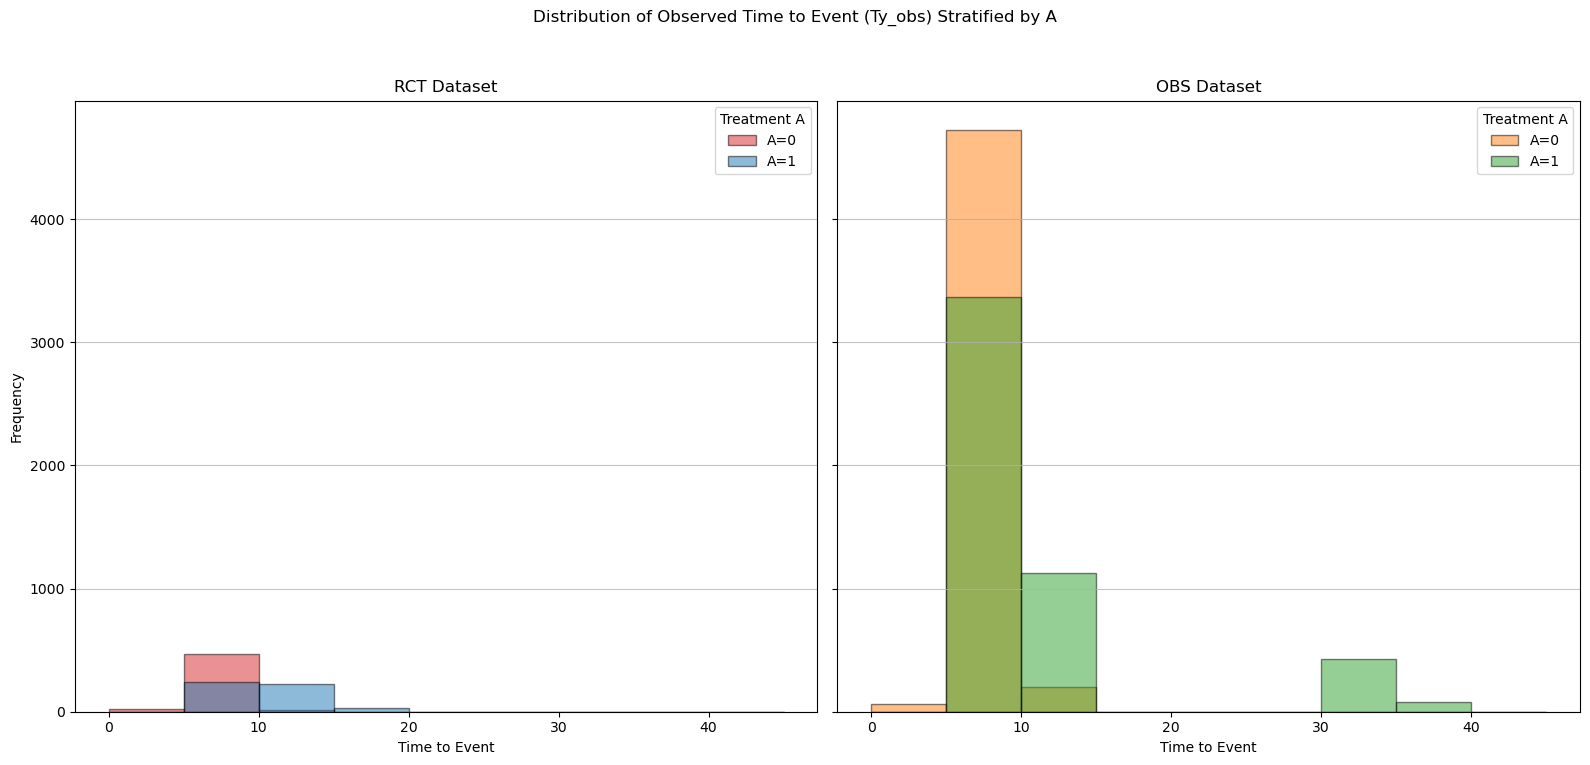

In [5]:
# Plot distribution of Ty_obs from df_obs and df_rct stratified by A using subplots
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(16, 8))

# Define bins for the histogram
bins = np.arange(0, 50, 5)

# Create two subplots: one for RCT and one for OBS
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Plot for RCT Data
axes[0].hist(
    df_rct[df_rct["A"] == 0]["Ty_obs"],
    bins=bins,
    alpha=0.5,
    label="A=0",
    color="tab:red",
    edgecolor='black'
)
axes[0].hist(
    df_rct[df_rct["A"] == 1]["Ty_obs"],
    bins=bins,
    alpha=0.5,
    label="A=1",
    color="tab:blue",
    edgecolor='black'
)
axes[0].set_title("RCT Dataset")
axes[0].set_xlabel("Time to Event")
axes[0].set_ylabel("Frequency")
axes[0].legend(title="Treatment A")
axes[0].grid(axis='y', alpha=0.75)

# Plot for OBS Data
axes[1].hist(
    df_obs[df_obs["A"] == 0]["Ty_obs"],
    bins=bins,
    alpha=0.5,
    label="A=0",
    color="tab:orange",
    edgecolor='black'
)
axes[1].hist(
    df_obs[df_obs["A"] == 1]["Ty_obs"],
    bins=bins,
    alpha=0.5,
    label="A=1",
    color="tab:green",
    edgecolor='black'
)
axes[1].set_title("OBS Dataset")
axes[1].set_xlabel("Time to Event")
axes[1].legend(title="Treatment A")
axes[1].grid(axis='y', alpha=0.75)

plt.suptitle("Distribution of Observed Time to Event (Ty_obs) Stratified by A")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

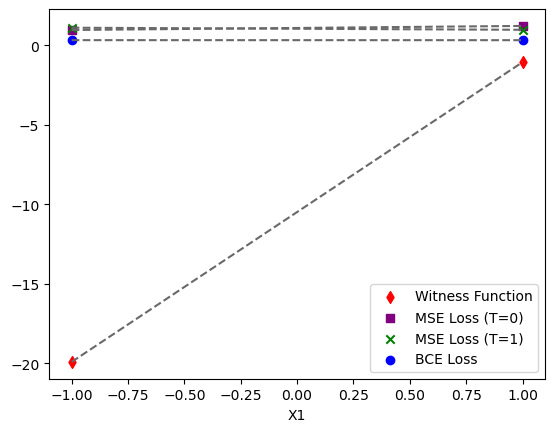

In [7]:
wf = np.zeros(2)
wf[0] = df_merged.query("X1 == -1")["psi"].dropna().mean()
wf[1] = df_merged.query("X1 == 1")["psi"].dropna().mean()

bceloss = np.zeros(2)
bceloss[0] = df_merged.query("S==0 & X1==-1")["BCELoss_A"].dropna().mean()
bceloss[1] = df_merged.query("S==0 & X1==1")["BCELoss_A"].dropna().mean()

mseloss_t0 = np.zeros(2)
mseloss_t0[0] = df_merged.query("S==0 & X1==-1 & A==0")["SE_Y0"].dropna().mean()
mseloss_t0[1] = df_merged.query("S==0 & X1==1 & A==0")["SE_Y0"].dropna().mean()

mseloss_t1 = np.zeros(2)
mseloss_t1[0] = df_merged.query("S==0 & X1==-1 & A==1")["SE_Y1"].dropna().mean()
mseloss_t1[1] = df_merged.query("S==0 & X1==1 & A==1")["SE_Y1"].dropna().mean()

plt.figure()

plt.plot([-1,1], wf, ls='--', color="dimgray")
plt.scatter([-1,1], wf, marker='d', color='r',  label="Witness Function",)

plt.plot([-1,1], mseloss_t0, ls='--', color="dimgray")
plt.scatter([-1,1], mseloss_t0, marker='s', color='purple', label="MSE Loss (T=0)")

plt.plot([-1,1], mseloss_t1, ls='--', color="dimgray")
plt.scatter([-1,1], mseloss_t1, marker='x', color='g', label="MSE Loss (T=1)")

plt.plot([-1,1], bceloss, ls='--', color="dimgray")
plt.scatter([-1,1], bceloss, marker='o', color='b', label="BCE Loss")

# plt.ylim(-20,50)
plt.xlabel("X1")
plt.legend()
plt.show()